# YouNiverse: Mapping YouTube's Hidden Communities

## Project Abstract

This project aims to uncover the hidden architecture of YouTube's content landscape. Instead of relying on explicit channel categories, we build a graph based on **audience overlap**. 

The core logic is this: for each user, we find the **Top-K channels** they comment on the most. We then create edges *only* between these Top-K channels. This creates a high-signal graph of true audience affinity.

This notebook documents the end-to-end pipeline by calling scripts from our `src` directory:

1.  **Data Loading:** Ingest channel and video metadata using `src.data.load`.
2.  **Graph Construction:** Stream comments to build the Top-K co-commenter graph using `src.scripts.process_data`.
3.  **Graph Analysis:** Normalize the graph (using our new commenter counts), run community detection, and calculate metrics using `src.models.analysis`.
4.  **Results:** Analyze and visualize the resulting communities.

## 1. Setup and Imports

First, we set up our environment, adding the `src` directory to the path and importing our custom-built modules.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import sys
import os
import matplotlib.pyplot as plt

# Add src to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import our custom modules
from src.data import data_loader 
from src.scripts import process_data as data_processor
from src.models import model_analysis as model_analyzer

print("Successfully imported src modules.")

Successfully imported src modules.


### Configuration

We set our main analysis parameters here. These will be passed to our scripts.

In [3]:
# --- Parameters ---
MIN_SUBSCRIBERS = 200_000
MIN_EDGE_WEIGHT = 3
MAX_COMMENT_ROWS = 150_000_000 

# --- New Top-K Parameters ---
TOP_K_PER_AUTHOR = 5
MIN_CHANS_FOR_PAIRS = 2
AUTHOR_FLUSH_THRESHOLD = 500_000

# --- Normalization Parameters ---
NORM_ALPHA = 0.5
NORM_BETA = 1.0
USE_ENGAGEMENT_METRIC = True # Use commenter counts

# --- File Paths (relative to project root) ---
CHANNEL_METADATA_PATH = "data/raw/df_channels_en.tsv" 
VIDEO_METADATA_PATH = "data/raw/yt_metadata_helper.feather"

EDGES_OUT_PATH = "data/processed/channel_edges.csv"
CHECKPOINT_PATH = "data/processed/edges_checkpoint.pkl"
STATE_PATH = "data/processed/state.json"
DICT_PATH = "data/processed/channel_commenter_counts.csv"

NODES_OUT_PATH = "data/processed/chan_graph_node_metrics.csv"
COMMUNITIES_OUT_PATH = "data/processed/chan_graph_community_summary.csv"
VIZ_OUT_PATH = "reports/figures/network_viz.png"

# Ensure processed/reports directories exist
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

print("Configuration and paths set.")

Configuration and paths set.


## 2. Data Loading and Preparation

First, we load the metadata we need to build our helper maps.
1.  **Channel Metadata:** To get subscriber counts for filtering.
2.  **Video Metadata:** To create a lookup map from `video_id` to `channel_id`.



In [4]:
# Load data using our loader script
dfChannels = pd.read_csv(CHANNEL_METADATA_PATH,sep='\t')
videoDf = data_loader.load_video_metadata(local_path=VIDEO_METADATA_PATH, columns=["display_id", "channel_id"])

# Create helper maps using our processing script
v2c_map = data_processor.build_video_to_channel_map(videoDf)
channel_subset_map = data_processor.get_channel_subset_map(dfChannels, MIN_SUBSCRIBERS)

del videoDf # Free up memory

Loading Video Metadata...
Loaded 72,924,794 video records.
Creating 72,924,794 v2c mappings...
Created channel subset map. 25,956 channels selected.


## 3. Graph Construction: Streaming Comments

This is the most computationally intensive step. We call our `generate_edges` script.

As this probably would take too long to run on a personal computer without a graphic card, we created a notebook to be ran on a cloud computing platform like Google colab in src/data/data_loader.ipynb that creates edges and channel dictionary. They should be put in EDGES_OUT_PATH and DICT_PATH.

This function will stream comments, process them using the **Top-K logic**, and save both `channel_edges.csv` and the new `channel_commenter_counts.csv`.

It is also possible to create the graph only for videos published during a specific range of time. That is also shown in src/data/dataloader.ipynb. This will allow us to show the graph progress through time.

In [5]:
v2c_map = None
'''
edges_df = data_processor.generate_edges(
    v2c_map,
    EDGES_OUT_PATH,
    CHECKPOINT_PATH,
    STATE_PATH,
    DICT_PATH,
    max_rows=MAX_COMMENT_ROWS,
    top_k_per_author=TOP_K_PER_AUTHOR,
    min_chans_for_pairs=MIN_CHANS_FOR_PAIRS,
    author_flush_threshold=AUTHOR_FLUSH_THRESHOLD
)'''
edges_df = pd.read_csv(EDGES_OUT_PATH)
print(f"\nSuccessfully loaded {len(edges_df):,} edges.")
edges_df.head()


Successfully loaded 32,408,399 edges.


,src,dst,weight
0,UCBXNpF6k2n8dsI6nBH8q4sQ,UCM2ERkgV3P1_6MAyxa51rxA,29
1,UCBXNpF6k2n8dsI6nBH8q4sQ,UCpB959t8iPrxQWj7G6n0ctQ,98
2,UCBXNpF6k2n8dsI6nBH8q4sQ,UCtwD0AlYSlAYv7eXu8UxtEg,5
3,UCM2ERkgV3P1_6MAyxa51rxA,UCpB959t8iPrxQWj7G6n0ctQ,431
4,UCM2ERkgV3P1_6MAyxa51rxA,UCtwD0AlYSlAYv7eXu8UxtEg,10


## 4. Graph Analysis Pipeline

Now we run the main analysis pipeline. Let us find communities of similar channels based on audience. 

We will normalize our graph. The problem now is that two big channels will automatically have an edge between them with a high enough weight to shadow two smaller channels with the same edge weight but which is way more representative of channel similarity proportionally to their size. 

For example, Channel 1 and Channel 2 both have 500k total commenters that we scraped from the data. The edge weight is 10k meaning 10k of these users commented both on videos from channel 1 and channel 2. Proportionally to the channel size this is not a huge value. <br/>
On the other hand we have Channel 3 and 4 which both have 10k commenters. This time the edge weight is 5k. Meaning approximately half of their audience is shared! Edge weight is then not the best indicator channel similarity <br/> <br/>
Knowing this, we normalize edge weight to get more of a "similarity score" and find more niche communities.

In [6]:

edges_filtered, channels_indexed = model_analyzer.filter_edges(
    edges_df, dfChannels, MIN_SUBSCRIBERS, MIN_EDGE_WEIGHT
)

commenter_counts = data_loader.load_commenter_counts(DICT_PATH)

edges_normalized = model_analyzer.normalize_edges(
    edges_filtered, 
    channels_indexed, 
    commenter_counts, 
    alpha=NORM_ALPHA, 
    beta=NORM_BETA, 
    use_engagement=USE_ENGAGEMENT_METRIC
)


G = model_analyzer.build_graph(edges_normalized, channels_indexed)

LCC, communities, node_df, comm_summary = model_analyzer.find_communities(
    G, nodes_out_path=NODES_OUT_PATH, comm_out_path=COMMUNITIES_OUT_PATH
)

Filtering edges: >200000 subs, >3 weight.
Filtered down to 4,737,353 edges.
Loading commenter counts from data/processed/channel_commenter_counts.csv...
Loaded 129,996 channel commenter counts.
Normalizing edge weights...
Using commenters (Top-K) (median=98) for normalization.
Building graph from normalized edges...
Graph built: 24,557 nodes, 4,737,353 edges
Finding Largest Connected Component (LCC)...
LCC:   24,557 nodes, 4,737,353 edges  (100.0% of nodes)
Detecting communities using Louvain...
Found 16 communities (modularity: 0.553)
Calculating node metrics (PageRank, Strength)...

✓ Saved node metrics and community summary.


## 5. Results and Interpretation

Our pipeline is complete. The results are saved in `data/processed/`. We can now load them for analysis.

### Result 1: Top 10 Largest Communities

This table shows the largest "galaxies" we found, sorted by the number of channels they contain.

In [7]:
print("Top 10 Largest Communities:")
print(comm_summary.head(10).to_string(index=False))

Top 10 Largest Communities:
 community  n_nodes  total_strength  avg_degree  avg_strength
         2     4402        27472309  392.767378   6240.869832
         5     4331        26812828  373.430616   6190.909259
         7     3895        28348795  346.069320   7278.252888
         0     3824        59257408  562.790795  15496.184100
         3     2941        32976986  437.942877  11212.848011
        11     1665         8559845  336.208408   5141.048048
        12      986         1831683  155.779919   1857.690669
         8      627         4636915  288.776715   7395.398724
         6      482         3418502  216.699170   7092.327801
        13      405          690703  141.866667   1705.439506


### Result 2: Top 10 Most Influential Channels

This table shows the top 10 channels ranked by **PageRank**. PageRank identifies channels that are connected to *other* influential channels. These are the "super-connectors" in our YouNiverse.

In [8]:
print("Top 10 Channels by PageRank:")
print(node_df.nlargest(10, "pagerank")[
    ["name_cc", "category_cc", "subscribers_cc", "community", "degree", "pagerank"]
].to_string(index=False))

Top 10 Channels by PageRank:
         name_cc          category_cc  subscribers_cc  community  degree  pagerank
       PewDiePie               Gaming       101000000          0   16567  0.010055
        T-Series                Music       112139463          7   10068  0.005934
          DanTDM               Gaming        22100000          0    9252  0.004172
   jacksepticeye               Gaming        22833014          0    9078  0.003543
      Markiplier               Gaming        24400000          0    9766  0.003482
Technical Guruji Science & Technology        13979890          7    6201  0.003466
     PopularMMOs               Gaming        16900000          0    7997  0.003329
       Jake Paul       People & Blogs        19600000          0    8668  0.003290
Logan Paul Vlogs        Entertainment        19800000          0    9977  0.003084
          SMTOWN                Music        19800000          2    8351  0.002837


### Result 3: Deep Dive into Community Profiles

We now call our analysis script to analyze the top communities. This helps us put a name and a theme to our algorithmically-defined clusters.

In [9]:
# Run the analysis script
model_analyzer.analyze_communities(LCC, node_df, communities, max_show=20)

--- Deep Dive into Top 5 Communities ---
COMMUNITY 0
Size: 3824 nodes, 531228 edges
Top category: Gaming (2002/3824) 
--------------------------------------------------------------------------------
Categories:
  Gaming               2002 (52.4%)
  Entertainment         702 (18.4%)
  Film and Animation    331 (8.7%)
  Comedy                222 (5.8%)
  People & Blogs        180 (4.7%)
--------------------------------------------------------------------------------
Top 5 Channels (by Subscribers):
      name_cc    category_cc  strength  subscribers_cc
    PewDiePie         Gaming   2440719       101000000
       DanTDM         Gaming   1309846        22100000
  PopularMMOs         Gaming   1080701        16900000
jacksepticeye         Gaming   1036979        22833014
    Jake Paul People & Blogs   1002203        19600000

COMMUNITY 1
Size: 133 nodes, 4946 edges
Top category: Entertainment (52/133) 
--------------------------------------------------------------------------------
Categori

### Result 4: Network Visualization

Finally, we call our visualization script to generate and save a plot of the graph.

**Nodes** are colored by their community and sized by their strength and the legend shows us the top youtuber by community.

Generating network visualization...
Visualization subgraph: 150 nodes, 5809 edges
✓ Saved reports/figures/network_viz.png


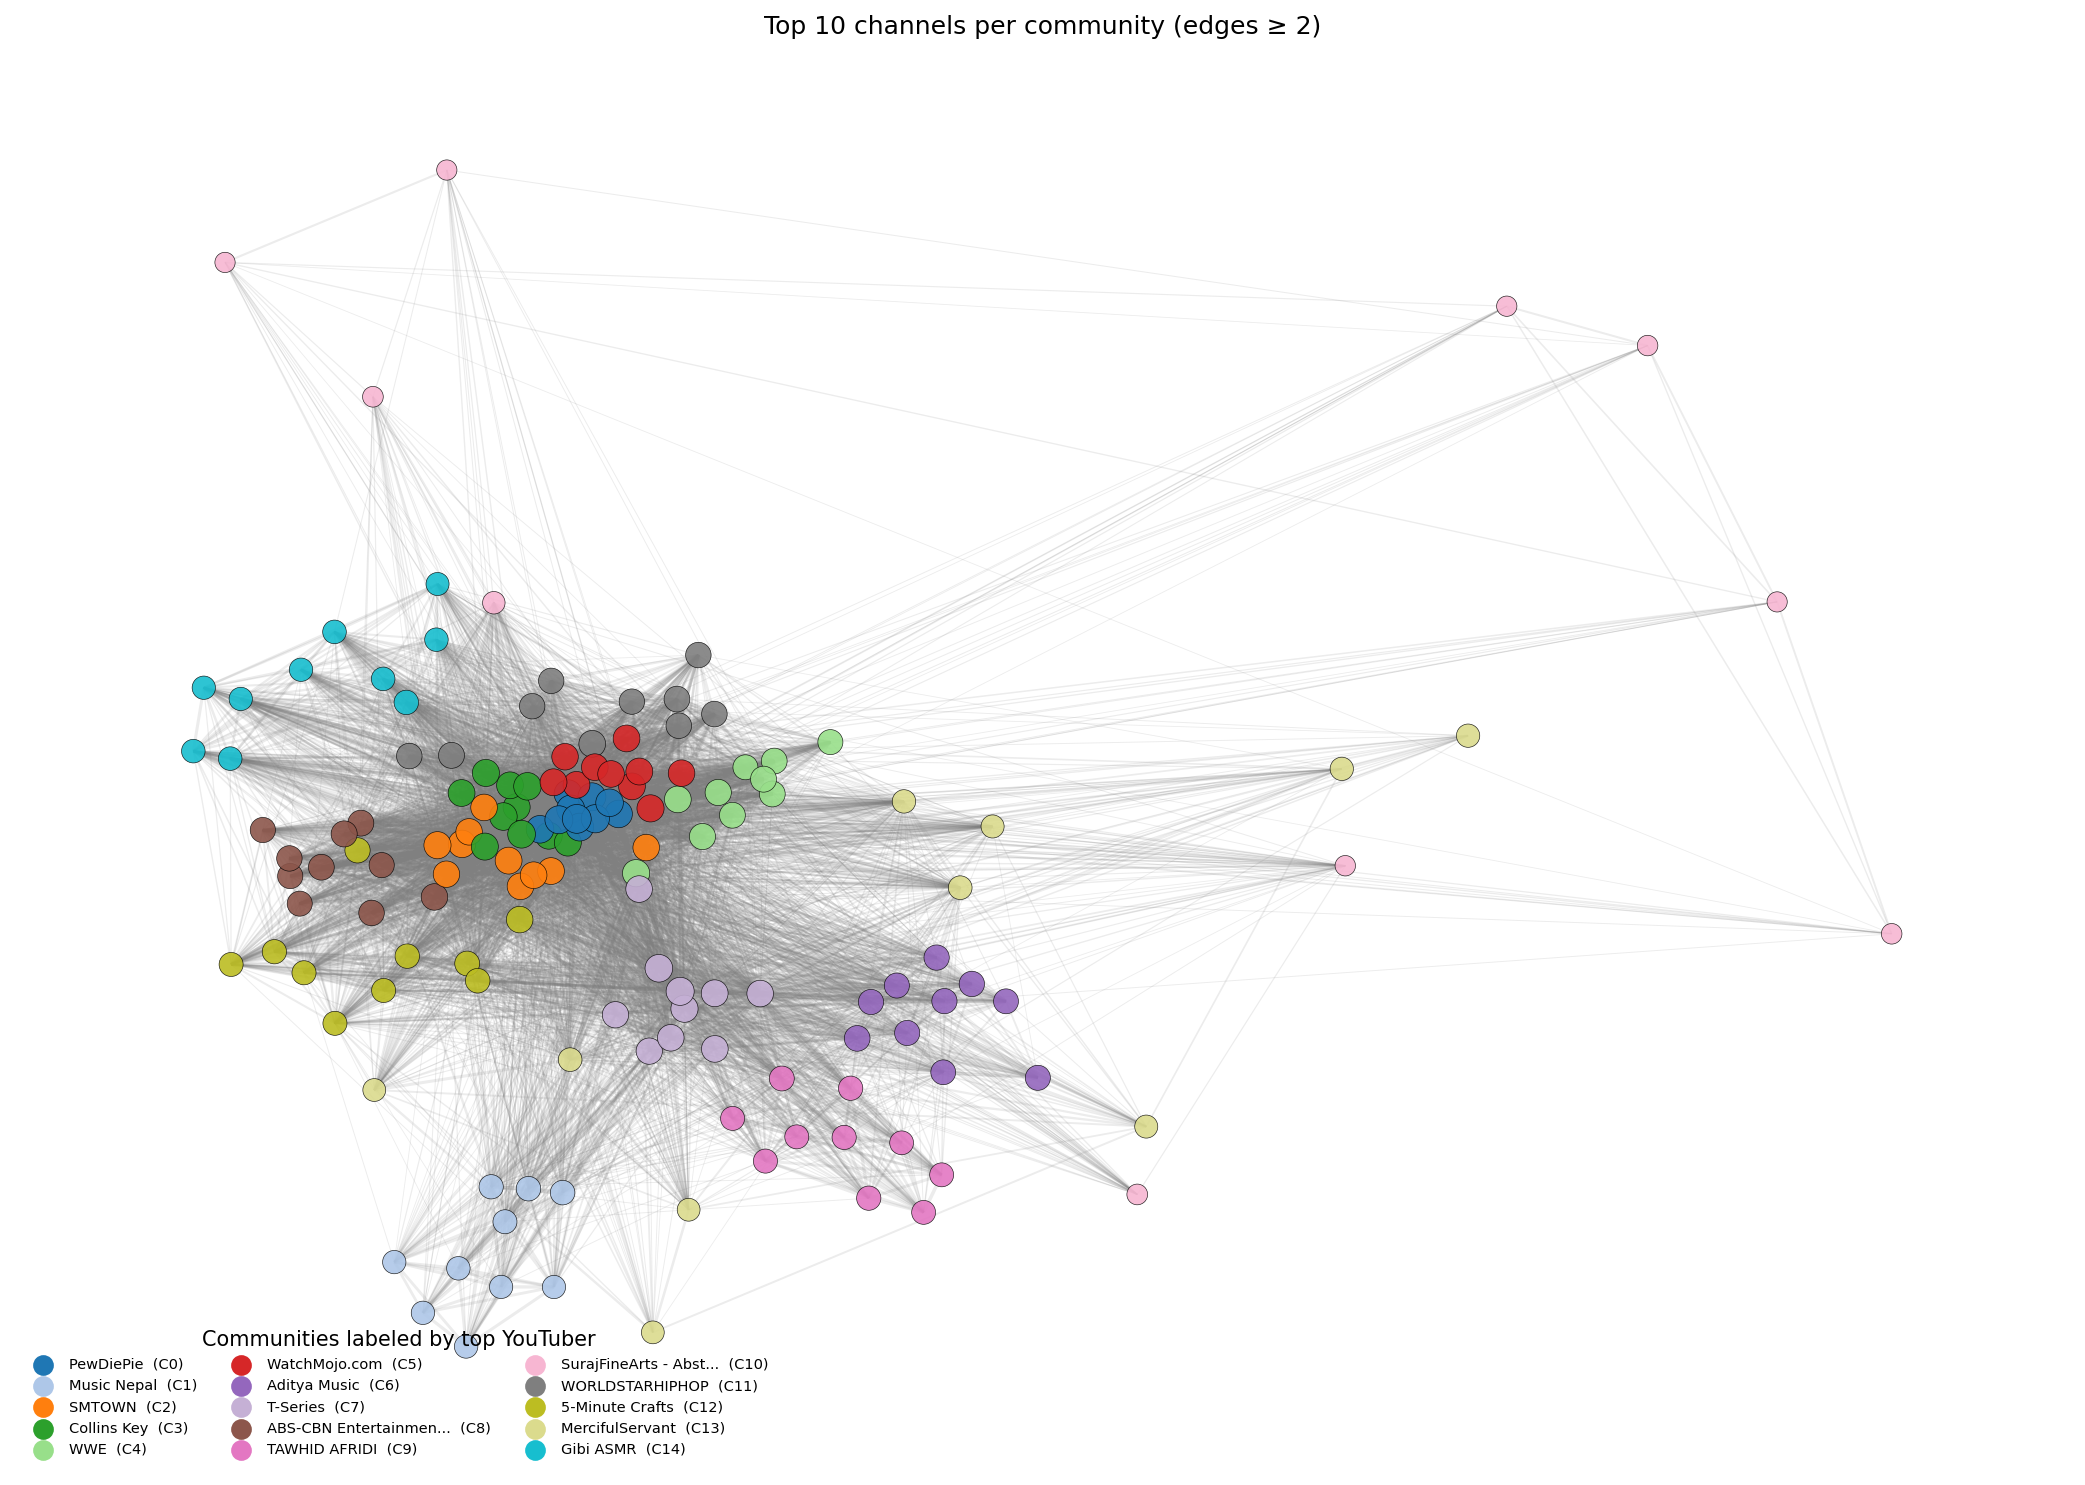

In [10]:
model_analyzer.visualize_network(
    LCC, 
    communities, 
    node_df, 
    viz_out_path=VIZ_OUT_PATH
)

### 6.1 Measuring how attention leaves a galaxy

Concretely, the code in this cell:
- maps each channel to its detected community,
- aggregates channel-to-channel interactions into **community-to-community flows**,
- separates internal from cross-community interactions,
- and derives several mobility indicators:
  - **external share** (how much attention leaves the community),
  - **destination diversity** (entropy / Gini),
  - **top destination share** (how concentrated exits are).

The goal is not yet to label communities, but to build **quantitative signals**
that describe *how audiences move once they leave their home galaxy*.

At this stage, we expect to observe heterogeneous behaviors: some communities may keep
most attention inside, while others may act as more open systems.


In [11]:
def gini(arr):
    # Simple Gini helper for a 1D array
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0 or np.allclose(arr.sum(), 0):
        return 0.0
    arr = np.sort(arr)
    n = arr.size
    cumx = np.cumsum(arr)
    return (n + 1 - 2 * (cumx / cumx[-1]).sum()) / n

# Map each channel to its community for quick lookups
channel_to_comm = node_df.set_index("channel_id")['community']

# Aggregate channel→channel edges up to community→community level
edges_comm = (
    edges_normalized[["src", "dst", "weight", "weight_raw"]]
    .assign(
        src_comm=lambda df: df["src"].map(channel_to_comm),
        dst_comm=lambda df: df["dst"].map(channel_to_comm),
    )
    .dropna(subset=["src_comm", "dst_comm"])
    .astype({"src_comm": int, "dst_comm": int})
)

# Flag cross-community edges for later cuts
edges_comm["is_cross"] = edges_comm["src_comm"] != edges_comm["dst_comm"]

# Build community-level flow matrices (normalized + raw)
communities_sorted = sorted(node_df["community"].unique())
pair_strength = edges_comm.groupby(["src_comm", "dst_comm"])[["weight", "weight_raw"]].sum().reset_index()
flow_norm = pd.DataFrame(0.0, index=communities_sorted, columns=communities_sorted)
flow_raw = pd.DataFrame(0.0, index=communities_sorted, columns=communities_sorted)
for _, row in pair_strength.iterrows():
    a, b, w_norm, w_raw = int(row.src_comm), int(row.dst_comm), row.weight, row.weight_raw
    flow_norm.loc[a, b] += w_norm
    flow_raw .loc[a, b] += w_raw

# Remove self-loops to focus on outbound shares
flow_norm_no_diag = flow_norm.copy()
np.fill_diagonal(flow_norm_no_diag.values, 0)
flow_share = flow_norm_no_diag.div(flow_norm_no_diag.sum(axis=1), axis=0).fillna(0)

# External share (cut/volume) using normalized weights
total_strength = (
    edges_comm.groupby("src_comm")["weight"].sum()
    .add(edges_comm.groupby("dst_comm")["weight"].sum(), fill_value=0)
)
cut_cross = edges_comm[edges_comm["is_cross"]].groupby(["src_comm", "dst_comm"])['weight'].sum()
cut_per_comm = cut_cross.groupby(level=0).sum().add(cut_cross.groupby(level=1).sum(), fill_value=0)
external_share = (cut_per_comm / total_strength).fillna(0)

# Diversity of destinations (entropy/Gini) + top destination share
mobility_rows = []
for cid in communities_sorted:
    row = flow_share.loc[cid]
    dests = row[row > 0]
    if dests.empty:
        entropy = 0.0
        top_share = 0.0
        gini_out = 0.0
    else:
        p = dests / dests.sum()
        entropy = -np.sum(p * np.log2(p))
        top_share = p.max()
        gini_out = gini(p)
    mobility_rows.append({
        "community": cid,
        "external_share": float(external_share.get(cid, 0)),
        "entropy_out": float(entropy),
        "gini_out": float(gini_out),
        "top_dest_share": float(top_share),
    })

# Most common category per community (ties broken by mode)
mode_category = node_df.groupby("community")["category_cc"].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown"
)

mobility_df = pd.DataFrame(mobility_rows).merge(
    comm_summary[["community", "n_nodes", "avg_degree"]], on="community", how="left"
).merge(mode_category.rename("top_category"), on="community", how="left")

# Rank communities from most closed to most open
mobility_df = mobility_df.sort_values(["external_share", "entropy_out"])
mobility_df.head(10)




,community,external_share,entropy_out,gini_out,top_dest_share,n_nodes,avg_degree,top_category
15,15,0.092908,0.000000,0.000000,0.000000,2,2.500000,Education
7,7,0.106496,3.339379,0.473191,0.162403,3895,346.069320,Entertainment
1,1,0.109265,1.988234,0.729282,0.648333,133,177.330827,Entertainment
6,6,0.156016,1.676360,0.788719,0.724989,482,216.699170,Entertainment
9,9,0.196726,1.387861,0.812551,0.792504,255,234.419608,Entertainment
8,8,0.258018,2.756575,0.631078,0.351190,627,288.776715,Entertainment
13,13,0.331056,2.911165,0.580814,0.219854,405,141.866667,Music
3,3,0.339180,2.693708,0.647208,0.266097,2941,437.942877,Howto & Style
0,0,0.343131,2.587096,0.676057,0.337803,3824,562.790795,Gaming
5,5,0.376897,2.612804,0.670566,0.311669,4331,373.430616,Gaming


### 6.2 Dominant destinations — who do communities send attention to?

After measuring how much attention leaves each community, we now look at *where* this
attention goes.

In this cell, the code:
- ranks destination communities by share of outgoing flow,
- identifies each community’s top partner (and second partner),
- and highlights cases where most external attention is concentrated on a single
destination.

This helps us detect **dependency patterns**, where communities rely heavily on a
specific external galaxy.


In [12]:
import seaborn as sns

# Find each community's top destinations (by share of outgoing flow)
top_partner_rows = []
for cid in communities_sorted:
    row = flow_share.loc[cid]
    if row.sum() == 0:
        continue  # no outbound flow to rank
    top_vals = row.sort_values(ascending=False).head(3)
    top_partner_rows.append({
        "community": cid,
        "top_partner": int(top_vals.index[0]),
        "share_to_top": float(top_vals.iloc[0]),
        "second_partner": int(top_vals.index[1]) if len(top_vals) > 1 else None,
        "share_to_second": float(top_vals.iloc[1]) if len(top_vals) > 1 else None,
    })

# Rank by strongest dependency on a single partner
top_partner_df = pd.DataFrame(top_partner_rows).sort_values("share_to_top", ascending=False)
display(top_partner_df.head(10))


,community,top_partner,share_to_top,second_partner,share_to_second
9,9,7,0.792504,5,0.043475
6,6,7,0.724989,5,0.070016
1,1,7,0.648333,2,0.105312
8,8,2,0.351190,0,0.153522
0,0,5,0.337803,3,0.215162
4,4,0,0.332450,5,0.197818
5,5,0,0.311669,2,0.285760
2,2,5,0.270583,3,0.198556
3,3,0,0.266097,2,0.257269
10,10,7,0.265862,3,0.263368


### 6.3 Global circulation patterns — identifying major inter-community corridors

So far, we have quantified how open communities are and how dependent they can be on
specific partners. We now take a step back and look at the **global circulation of
attention** across the Youniverse.

In this cell, the code:
- aggregates community-to-community flows into **undirected links** (ignoring direction),
- keeps only the strongest connections to reduce visual clutter,
- and visualizes these links in a chord-style layout.

The goal here is to reveal the **backbone of audience circulation**:
which community pairs exchange the most attention overall, regardless of direction.


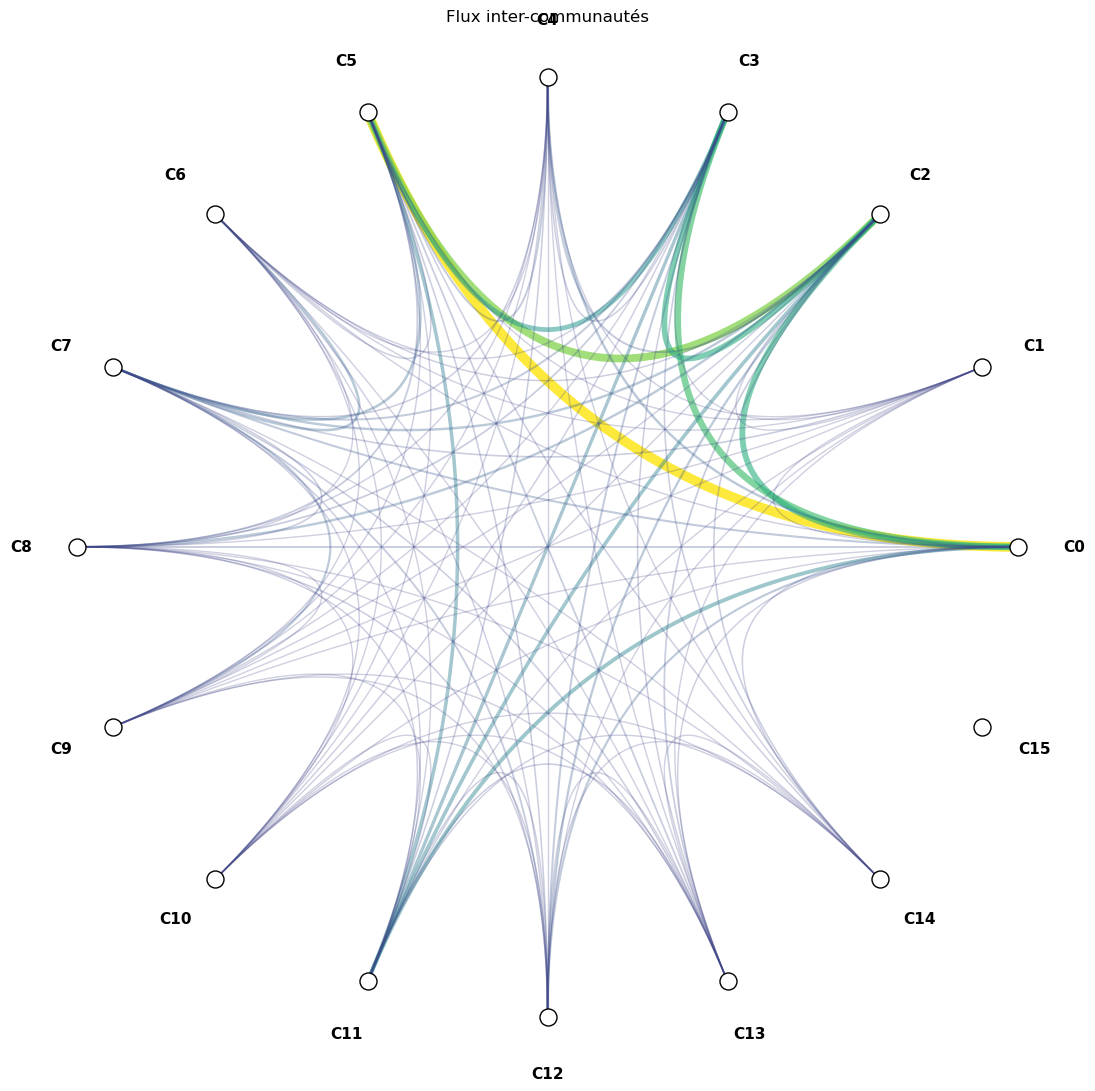

,c1,c2,weight
4,0,5,49131.536154
29,2,5,37531.360794
2,0,3,30853.131734
1,0,2,26613.876294
27,2,3,25868.319524
40,3,5,19981.136952
10,0,11,15001.829410
35,2,11,13359.295183
65,5,11,12682.656587
46,3,11,11424.902603


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Symmetrize flows (ignore direction) and keep the top 100 strongest links
flows = pair_strength.copy()
flows = flows[flows["src_comm"] != flows["dst_comm"]]
flows["a"] = flows[["src_comm", "dst_comm"]].min(axis=1)
flows["b"] = flows[["src_comm", "dst_comm"]].max(axis=1)
flows = flows.groupby(["a", "b"], as_index=False)["weight"].sum()
flows = flows.rename(columns={"a": "c1", "b": "c2"})
flows = flows.sort_values("weight", ascending=False).head(100)

# Place communities on a circle for the chord layout
order = sorted(communities_sorted)
theta = np.linspace(0, 2*np.pi, len(order), endpoint=False)
coords = {c: (np.cos(t), np.sin(t)) for c, t in zip(order, theta)}

# Style arcs by weight (thicker/darker = stronger flow)
w = flows["weight"]
w_norm = (w - w.min()) / (w.max() - w.min() + 1e-9)
widths = 1.0 + 6 * w_norm
colors = plt.cm.viridis(0.2 + 0.8 * w_norm)
alphas = 0.25 + 0.65 * w_norm

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Draw quadratic arcs via the center to connect pairs
for (c1, c2, weight), lw, col, a in zip(flows[["c1", "c2", "weight"]].itertuples(index=False, name=None), widths, colors, alphas):
    x0, y0 = coords[c1]
    x1, y1 = coords[c2]
    ctrl = np.array([0, 0])
    t = np.linspace(0, 1, 150)
    curve = (1 - t)[:, None]**2 * np.array([x0, y0]) + 2*(1 - t)[:, None]*t[:, None]*ctrl + t[:, None]**2 * np.array([x1, y1])
    ax.plot(curve[:,0], curve[:,1], color=col, alpha=a, linewidth=lw, solid_capstyle='round')

# Draw community nodes
for c in order:
    x, y = coords[c]
    ax.scatter(x, y, s=150, color="white", edgecolor="black", zorder=3)
    ax.text(x*1.12, y*1.12, f"C{c}", ha="center", va="center", fontsize=11, weight="bold")

ax.set_aspect('equal')
ax.axis('off')
plt.title("Flux inter-communautés", fontsize=12)
plt.tight_layout()
plt.savefig("reports/figures/community_chord_simple.png", dpi=150, bbox_inches="tight")
plt.show()

# Top undirected flows for interpretation
display(flows.sort_values("weight", ascending=False).head(10))


### 6.4 Echo-chamber candidates — combining openness and exit diversity

So far, we have looked separately at how much attention leaves each community and
where that attention goes. In this cell, we deliberately **combine these two signals**
to identify communities that are structurally inward-focused.

Concretely, the code:
- defines a low-openness threshold using the **25th percentile of external share**,
- defines a low-diversity threshold using the **median entropy of outgoing flows**,
- flags communities that satisfy *both* conditions:
  - few exits to other communities,
  - and concentrated destinations when exits do occur.

The goal is not to label echo chambers, but to identify **suspect communities**
whose interaction patterns stand out from the rest of the Youniverse.


Seuils: external_share <= 0.187, entropie <= 2.688
Communautés les plus fermées (tri multi-critères):


,community,external_share,entropy_out,gini_out,n_nodes,top_category
15,15,0.092908,0.000000,0.000000,2,Education
1,1,0.109265,1.988234,0.729282,133,Entertainment
6,6,0.156016,1.676360,0.788719,482,Entertainment


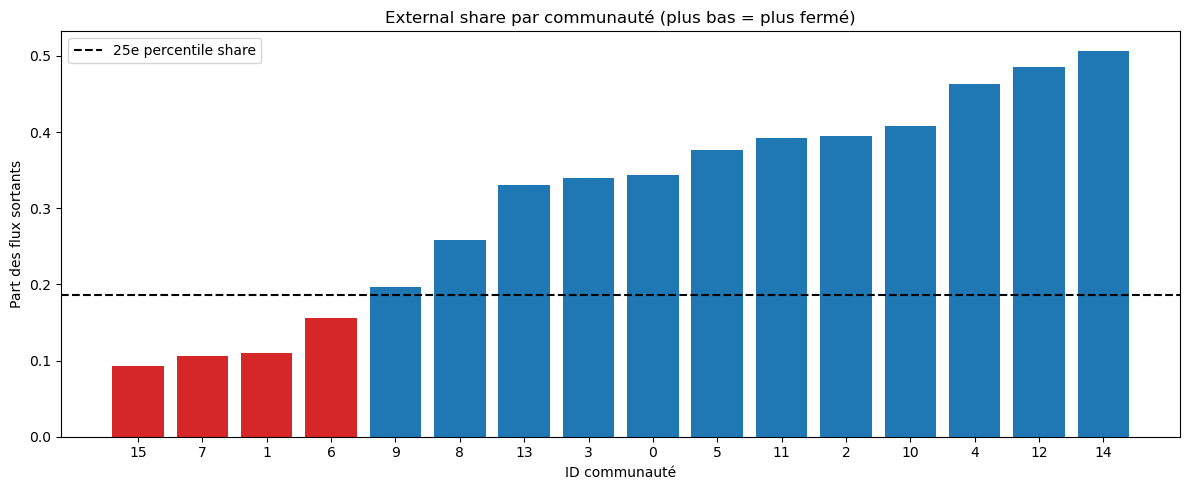

In [14]:
# Thresholds: closed if external share and entropy both fall below med/25th
q_ext = mobility_df["external_share"].quantile(0.25)
q_ent = mobility_df["entropy_out"].quantile(0.50)

# Keep only low-outflow, low-diversity communities
# (few exits and concentrated destinations)
echo_candidates = mobility_df[
    (mobility_df["external_share"] <= q_ext)
    & (mobility_df["entropy_out"] <= q_ent)
].copy()

echo_candidates = echo_candidates.sort_values(["external_share", "entropy_out"])

print(f"Seuils: external_share <= {q_ext:.3f}, entropie <= {q_ent:.3f}")
print("Communautés les plus fermées (tri multi-critères):")
display(echo_candidates.head(10)[[
    "community", "external_share", "entropy_out", "gini_out", "n_nodes", "top_category"
]])

# Bar plot with suspects in red
plt.figure(figsize=(12, 5))
colors = ["#d62728" if es <= q_ext else "#1f77b4" for es in mobility_df["external_share"]]
plt.bar(mobility_df["community"].astype(str), mobility_df["external_share"], color=colors)
plt.axhline(q_ext, color="black", linestyle="--", label="25e percentile share")
plt.ylabel("Part des flux sortants")
plt.xlabel("ID communauté")
plt.title("External share par communauté (plus bas = plus fermé)")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/echo_chamber_external_share.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.5 Bridge channels — identifying who enables cross-community travel

So far, we have characterized communities as more or less open systems.
In this cell, we change perspective again and zoom in at the **channel level** to ask:
*who* actually enables attention to move across communities?

Concretely, the code:
- computes an approximate **betweenness centrality** on the largest connected component,
  where strong links correspond to short paths,
- measures, for each channel, how much of its interaction strength goes to
  **other communities** (cross_share and cross_strength),
- and identifies **bridge channels** as those that:
  - send a majority of their attention outside their home community,
  - and carry a non-trivial volume of cross-community interaction.

The goal is to detect channels that structurally act as connectors between galaxies.


In [15]:
# Approx betweenness on the LCC (length = 1/weight so strong links are short)
G_bt = LCC.copy()
for u, v, d in G_bt.edges(data=True):
    w = d.get("weight", 1.0)
    d["length"] = 1 / (w + 1e-9)

# Sampled betweenness for speed (k=800 sources)
betweenness = nx.betweenness_centrality(G_bt, k=800, weight="length", seed=42)
node_df["betweenness"] = node_df["channel_id"].map(betweenness).fillna(0)

# Compute, for each channel, how much raw strength leaves its community
comm_map = node_df.set_index("channel_id")["community"].to_dict()
bridge_rows = []
for u in LCC.nodes():
    total_raw = 0.0
    cross_raw = 0.0
    for v, data in LCC[u].items():
        w = data.get("weight_raw", data.get("weight", 0))
        total_raw += w
        if comm_map.get(u) != comm_map.get(v):
            cross_raw += w
    cross_share = cross_raw / total_raw if total_raw > 0 else 0.0
    bridge_rows.append({
        "channel_id": u,
        "name": LCC.nodes[u].get("name_cc", u),
        "community": comm_map.get(u),
        "total_strength": total_raw,
        "cross_strength": cross_raw,
        "cross_share": cross_share,
        "degree": LCC.degree(u),
        "betweenness": betweenness.get(u, 0.0)
    })

bridge_df = pd.DataFrame(bridge_rows)
bridge_df = bridge_df.sort_values(["cross_share", "betweenness", "cross_strength"], ascending=[False, False, False])

# Bridges = channels with majority of strength outside and strong cross volume
bridge_top = bridge_df[(bridge_df["cross_share"] >= 0.5) & (bridge_df["cross_strength"] > 1000)]

print("Top canaux ponts (part vers d’autres communautés + betweenness):")
display(bridge_top.head(15)[[
    "name", "community", "cross_share", "cross_strength", "betweenness", "degree"
]])


Top canaux ponts (part vers d’autres communautés + betweenness):


,name,community,cross_share,cross_strength,betweenness,degree
17493,Jon Harris,10,0.971178,1550.0,2.494400e-05,251
2654,SurajFineArts - Abst...,10,0.945085,7211.0,6.872327e-05,914
8705,Fine Art-Tips,10,0.932798,1860.0,6.210548e-04,287
8706,LethalChris Drawing,10,0.930197,1226.0,2.759112e-05,182
17433,Lena Danya,10,0.921552,1069.0,1.546019e-04,173
5991,Crusoe the Dachshund...,12,0.920495,1042.0,3.889228e-05,163
8057,Mr Whaatwaa,13,0.920435,15224.0,7.191000e-04,1453
2295,Peggie Neo,11,0.919449,7682.0,1.578090e-06,807
333,Morpheus ASMR,14,0.919208,6178.0,1.883527e-06,686
5182,Humza Productions,11,0.917125,7503.0,8.919722e-06,668


### 6.6 Bridge categories — through which genres do audiences travel?

We have identified individual bridge channels that connect communities.
In this final step, we zoom out again and ask a higher-level question:
**are these bridges genre-specific, or do they reflect a broader mix of content?**

Concretely, the code:
- identifies the top bridge channels within each community,
- associates each channel with its content category,
- and aggregates bridge activity by **community × category**, measuring:
  - how many bridge channels belong to each category,
  - how much cross-community strength they carry,
  - and how dominant each category is within a community’s total bridging activity.

The goal is to understand whether cross-community travel is mediated by specific
content genres acting as a shared language across the Youniverse.


In [16]:

import seaborn as sns
from ipywidgets import interact, widgets

bridge_top_cat = bridge_top.merge(node_df[["channel_id", "category_cc"]], on="channel_id", how="left")

# Top channels per community (sorted by cross reach, then betweenness, then force)
top_channels = (
    bridge_df
    .merge(node_df[["channel_id", "category_cc"]], on="channel_id", how="left")
    .sort_values(["community", "cross_share", "betweenness", "cross_strength"],
                 ascending=[True, False, False, False])
    .groupby("community")
    .head(10)
)
print("Top bridge channels per community (max 10):")
display(top_channels[[
    "community", "name", "category_cc", "cross_share", "cross_strength", "betweenness", "degree"
]])

# Aggregate bridge categories per community
agg = (
    bridge_top_cat
    .groupby(["community", "category_cc"])
    .agg(
        n_channels=("channel_id", "count"),
        cross_strength=("cross_strength", "sum"),
        avg_cross_share=("cross_share", "mean"),
    )
    .reset_index()
)
agg["share_strength"] = agg.groupby("community")["cross_strength"].transform(
    lambda s: s / s.sum()
)
print("Bridge categories per community:")
display(agg.head(20))



Top bridge channels per community (max 10):


,community,name,category_cc,cross_share,cross_strength,betweenness,degree
28,0,Happy Toy Dolls,Education,0.937107,149.0,0.000100,24
126,0,TRA HUNG VINH,Howto & Style,0.886364,39.0,0.000026,9
221,0,Smyths Toys Supersto...,Entertainment,0.852941,29.0,0.000071,7
223,0,Life & Style,People & Blogs,0.852941,58.0,0.000001,14
531,0,Hitachi Cooling & He...,Science & Technology,0.797980,79.0,0.000003,19
...,...,...,...,...,...,...,...
123,14,ASMRTheChew,People & Blogs,0.886601,10031.0,0.000026,958
138,14,Cordylobia Anthropop...,Pets & Animals,0.881849,4217.0,0.000021,581
153,14,Good Eating ASMR,Entertainment,0.876818,3075.0,0.000019,379
969,15,Kids and Toys,Entertainment,0.750000,15.0,0.000041,4


Bridge categories per community:


,community,category_cc,n_channels,cross_strength,avg_cross_share,share_strength
0,0,Autos & Vehicles,1,2426.0,0.545291,0.000666
1,0,Comedy,17,70573.0,0.564918,0.019360
2,0,Education,13,79708.0,0.547742,0.021866
3,0,Entertainment,85,841338.0,0.564977,0.230802
4,0,Film and Animation,28,120187.0,0.560980,0.032971
5,0,Gaming,50,1885275.0,0.551696,0.517182
6,0,Howto & Style,12,352890.0,0.563090,0.096807
7,0,Music,8,24299.0,0.548748,0.006666
8,0,News & Politics,1,13528.0,0.589532,0.003711
9,0,People & Blogs,9,106932.0,0.533146,0.029334


### 6.7 Inspecting bridge channels locally — zooming inside each community

After identifying bridge channels and aggregating their categories, we now take a more
granular look at **which specific channels act as bridges within each community**.

The code in this cell was originally designed as an interactive tool:
- for a selected community, it displays the top bridge channels,
- ranked by cross-community interaction strength,
- and annotated with the share of attention leaving the community.

For reporting purposes, we also provide a static version that shows the top bridge
channels **across all communities at once**, allowing for global comparison.

The goal here is not to compare communities quantitatively, but to qualitatively inspect
*who* the main connectors are and how consistent their behavior is across the Youniverse.


interactive(children=(Dropdown(description='Community', options=(np.int64(0), np.int64(1), np.int64(2), np.int…

/var/folders/tb/9znx1kyn0x19c68yn465nk080000gn/T/ipykernel_80702/2506293123.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


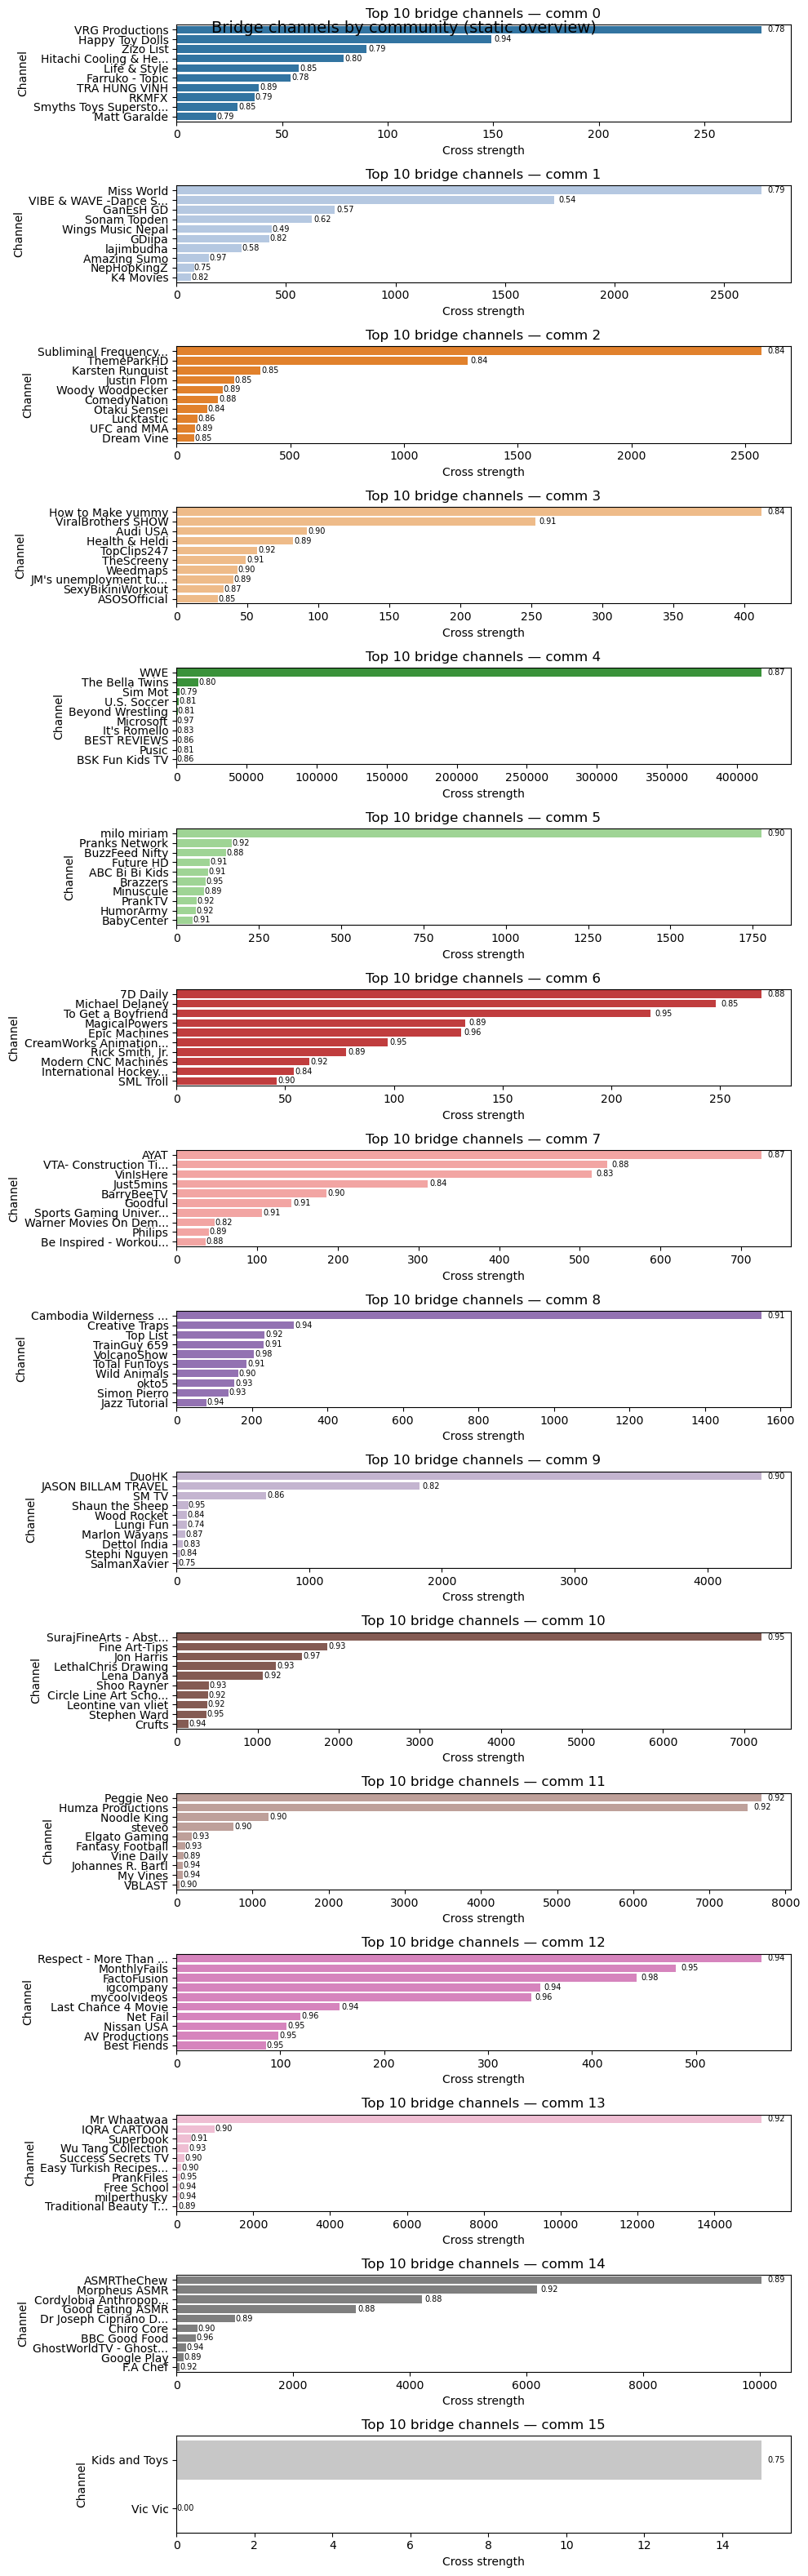

In [ ]:
# Interactive bar: inspect top bridge channels per community
communities = sorted(top_channels["community"].unique())
palette = sns.color_palette("tab20", len(communities))
comm_color = {c: palette[i % len(palette)] for i, c in enumerate(communities)}

@interact(comm=widgets.Dropdown(options=communities, description="Community"))
def plot_top_channels_by_comm(comm):
    # Sort by cross strength to surface the biggest movers first
    data = top_channels[top_channels["community"] == comm].sort_values("cross_strength", ascending=False)
    if data.empty:
        print("No bridge channels for this community.")
        return
    plt.figure(figsize=(9, max(4, 0.4 * len(data))))
    sns.barplot(
        data=data,
        y="name",
        x="cross_strength",
        color=comm_color.get(comm, "#1f77b4")
    )
    for i, row in data.reset_index().iterrows():
        plt.text(row["cross_strength"] * 1.01, i, f"share {row['cross_share']:.2f}", va="center", fontsize=7)
    plt.xlabel("Cross strength (raw weight)")
    plt.ylabel("Channel")
    plt.title(f"Top bridge channels — community {comm}")
    plt.tight_layout()
    plt.show()


topN = 10  # combien de channels afficher par communauté
fig, axes = plt.subplots(
    nrows=len(communities), figsize=(10, max(4, 2*len(communities))),
    constrained_layout=True, sharex=False
)
if len(communities) == 1:
    axes = [axes]

for ax, comm in zip(axes, communities):
    data = top_channels[top_channels["community"] == comm].sort_values("cross_strength", ascending=False).head(topN)
    if data.empty:
        ax.set_axis_off()
        continue
    sns.barplot(
        data=data,
        y="name",
        x="cross_strength",
        color=comm_color.get(comm, "#1f77b4"),
        ax=ax
    )
    for i, row in data.reset_index().iterrows():
        ax.text(row["cross_strength"] * 1.01, i, f"{row['cross_share']:.2f}", va="center", fontsize=7)
    ax.set_ylabel("Channel")
    ax.set_xlabel("Cross strength")
    ax.set_title(f"Top {topN} bridge channels — comm {comm}")
plt.suptitle("Bridge channels by community (static overview)", fontsize=14)
plt.tight_layout()
plt.savefig("reports/figures/bridge_channels_static_overview.png", dpi=150, bbox_inches="tight")
plt.show()




### 6.8 Which genres connect galaxies? — bridge categories at the community level

We have identified bridge channels and inspected them locally within each community.
In this final analytical step, we abstract one level higher and focus on **content
categories** rather than individual channels.

In this cell, the code:
- aggregates bridge channels by **community × category**,
- measures the total cross-community interaction strength carried by each category,
- and visualizes, for each community, the **top three bridge categories**.

The goal is to understand whether audience travel across the Youniverse is associated
with specific genres that consistently act as connectors between otherwise distinct
communities.


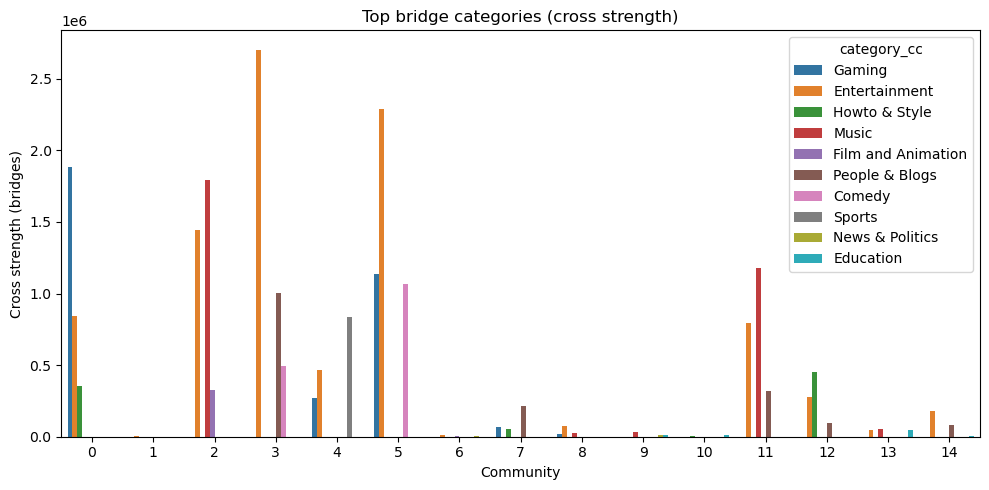

In [18]:

# Grouped bars: top 3 bridge categories per community
cat_top3 = (
    agg.sort_values(["community", "cross_strength"], ascending=[True, False])
       .groupby("community")
       .head(3)
)

# Highest-volume bridge categories per community (top 3 each)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=cat_top3,
    x="community",
    y="cross_strength",
    hue="category_cc",
    palette="tab10"
)
plt.ylabel("Cross strength (bridges)")
plt.xlabel("Community")
plt.title("Top bridge categories (cross strength)")
plt.tight_layout()
plt.savefig("reports/figures/bridge_categories_top3.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.9 Directional travel corridors — who sends attention to whom?

So far, we have looked at inter-community circulation in an undirected way, focusing
on overall exchange strength. In this cell, we explicitly reintroduce **directionality**
to study *who sends attention to whom*.

Concretely, the code:
- reshapes the community-to-community flow matrix into a long format,
- keeps only non-zero cross-community flows,
- ranks the strongest **directional** flows using normalized weights,
- and visualizes the top source → destination pairs.

The goal is to identify asymmetric travel patterns and detect communities that act
as major **senders**, **receivers**, or mutual exchange partners.


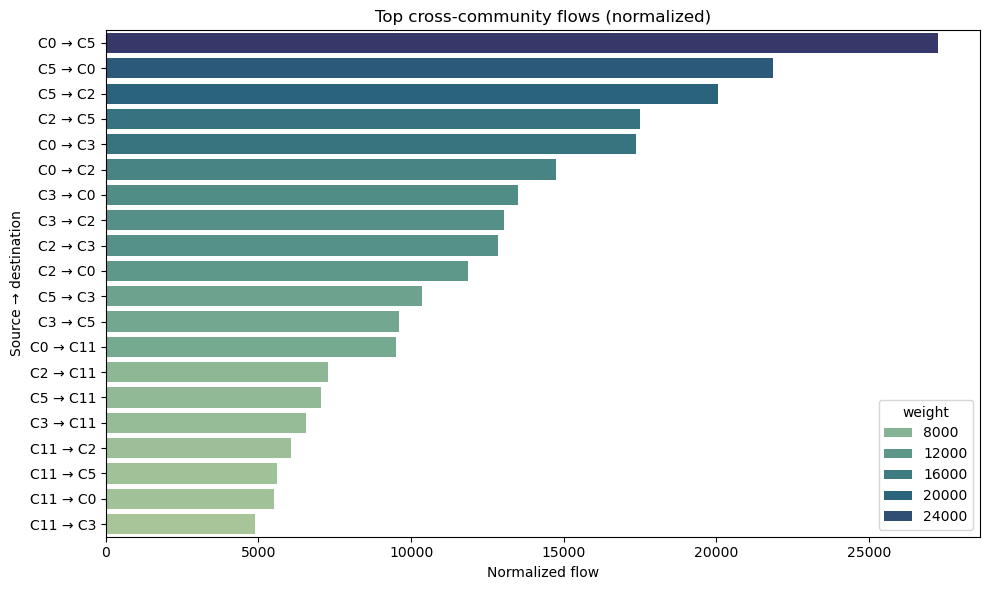

In [19]:

# Alternative view: rank the strongest normalized cross-community flows
flow_long = flow_norm.stack().reset_index()
flow_long.columns = ["community_src", "community_dst", "weight"]
flow_long = flow_long[flow_long["community_src"] != flow_long["community_dst"]]
flow_long = flow_long[flow_long["weight"] > 0]
top_flows = flow_long.sort_values("weight", ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_flows,
    y=top_flows.apply(lambda r: f"C{int(r.community_src)} → C{int(r.community_dst)}", axis=1),
    x="weight",
    hue="weight",
    palette="crest"
)
plt.xlabel("Normalized flow")
plt.ylabel("Source → destination")
plt.title("Top cross-community flows (normalized)")
plt.tight_layout()
plt.savefig("reports/figures/bridge_community_topflows.png", dpi=150, bbox_inches="tight")
plt.show()
